# Calibration vs. science frames at four pointings

Pick the first and last pointings (by chronological time) in each of the
two datasets that have all four (LO, noise_on) combinations available, and
compare the noise-on and noise-off spectra at each LO.

Layout: 4 rows x 2 columns. Rows: streaming start, streaming end, main start,
main end. Columns: LO1, LO2. Each panel overlays mean noise-on and
noise-off spectra at that pointing/LO. Uses `corr11` (Stokes pol-1) for both
datasets so the y-axis is comparable.

Scanning streaming...
  1638 pointings
  start: (l=86, b=+4), first dump t=1776333476
  end: (l=239, b=-3), first dump t=1777003454
Scanning main...
  1000 pointings
  start: (l=113.99, b=-4), first dump t=1777109460
  end: (l=213.13, b=+3), first dump t=1777439774


/tmp/ipykernel_27529/4012198066.py:130: RuntimeWarning: Mean of empty slice
  pol0_mean = np.nanmean([e[1] for e in entries], axis=0)
/tmp/ipykernel_27529/4012198066.py:131: RuntimeWarning: Mean of empty slice
  pol1_mean = np.nanmean([e[2] for e in entries], axis=0)


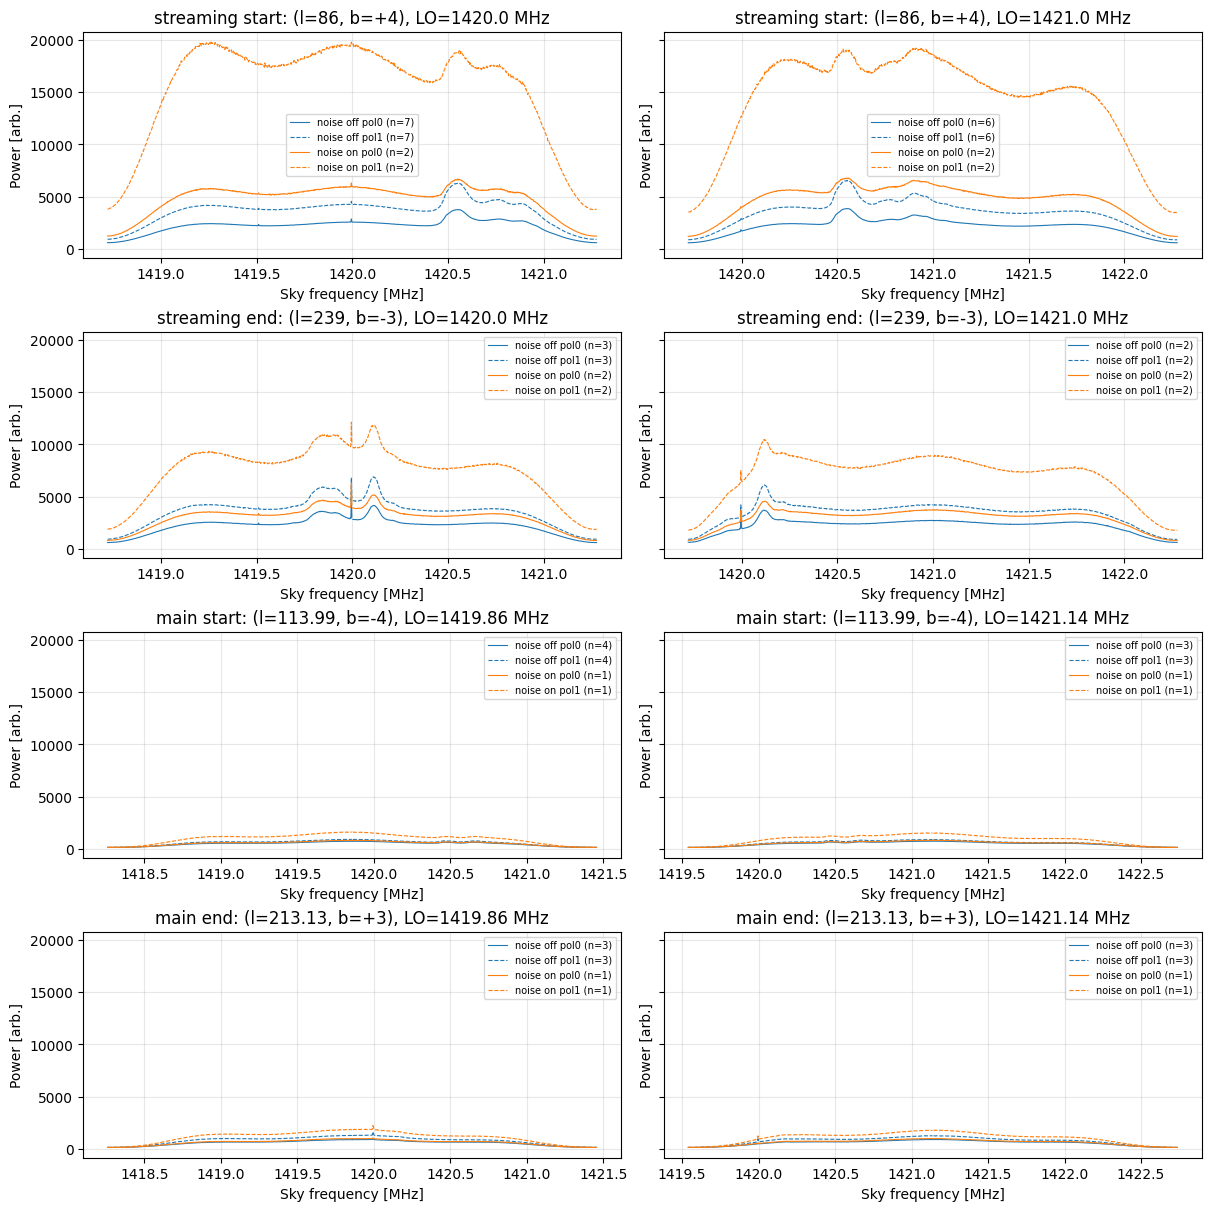

In [5]:
import sys
sys.path.insert(0, '..')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NFFT = 1024
DC_BIN = NFFT // 2  # mask after fftshift

DATASETS = {
    'streaming': {
        'dir': Path('../../../data/lab04/streaming'),
        'sample_rate_hz': 2.56e6,
        'lo1': 1420.0,
        'lo2': 1421.0,
    },
    'main': {
        'dir': Path('../../../data/lab04/main'),
        'sample_rate_hz': 3.2e6,
        'lo1': 1419.86,
        'lo2': 1421.14,
    },
}


def _parse_lb(name):
    """Parse 'obs_{l}_{b}' or 'cal_{l}_{b}'.

    Streaming uses integer l/b ('obs_120_0'); main encodes the decimal
    point as 'p' ('cal_101p96_-4' means l=101.96, b=-4).
    """
    parts = name.split('_', 2)
    if len(parts) != 3:
        return None
    l_str, b_str = parts[1].replace('p', '.'), parts[2].replace('p', '.')
    try:
        return float(l_str), float(b_str)
    except ValueError:
        return None


def collect_dataset(cfg):
    """Return {(l, b): {(lo_mhz, noise_on): [(time, pol0, pol1), ...]}}.

    Both polarizations are loaded; DC bin is masked in each.
    """
    cells = {}
    for session_dir in sorted(cfg['dir'].glob('session_*')):
        for cell_dir in sorted(session_dir.iterdir()):
            if not cell_dir.is_dir():
                continue
            name = cell_dir.name
            if not (name.startswith('obs_') or name.startswith('cal_')):
                continue
            lb = _parse_lb(name)
            if lb is None:
                continue
            l, b = lb
            for p in sorted(cell_dir.glob('*.npz')):
                with np.load(p, allow_pickle=True) as f:
                    lo = float(f['lo_freq_mhz'])
                    on = bool(f['noise_on'])
                    t = float(f['time'])
                    pol0 = np.fft.fftshift(f['corr00'].astype(float))
                    pol1 = np.fft.fftshift(f['corr11'].astype(float))
                pol0[DC_BIN] = np.nan
                pol1[DC_BIN] = np.nan
                cells.setdefault((l, b), {}).setdefault((lo, on), []).append(
                    (t, pol0, pol1)
                )
    return cells


def pick_first_last(cells, lo1, lo2):
    """First and last cells (by earliest dump time) with all 4 (lo, on) combos."""
    needed = [(lo1, True), (lo1, False), (lo2, True), (lo2, False)]
    cands = []
    for (l, b), specs in cells.items():
        if not all(k in specs and specs[k] for k in needed):
            continue
        t_min = min(t for k in needed for (t, *_) in specs[k])
        cands.append((t_min, l, b, specs))
    if len(cands) < 2:
        return None
    cands.sort()
    return cands[0], cands[-1]


def _fmt_lb(l, b):
    l_s = f'{int(l)}' if float(l).is_integer() else f'{l:.2f}'
    b_s = f'{int(b):+d}' if float(b).is_integer() else f'{b:+.2f}'
    return l_s, b_s


selected = []
for name, cfg in DATASETS.items():
    print(f'Scanning {name}...')
    cells = collect_dataset(cfg)
    print(f'  {len(cells)} pointings')
    pair = pick_first_last(cells, cfg['lo1'], cfg['lo2'])
    if pair is None:
        print(f'  WARNING: not enough cells with all 4 (LO, noise) combos')
        continue
    first, last = pair
    for tag, (t_min, l, b, specs) in [('start', first), ('end', last)]:
        selected.append((name, tag, l, b, specs))
        l_s, b_s = _fmt_lb(l, b)
        print(f'  {tag}: (l={l_s}, b={b_s}), first dump t={t_min:.0f}')

f_bb_cache = {
    name: np.fft.fftshift(np.fft.fftfreq(NFFT, 1.0 / cfg['sample_rate_hz'])) / 1e6
    for name, cfg in DATASETS.items()
}

# Style: noise-off = C0, noise-on = C1; pol0 = solid, pol1 = dashed.
fig, axes = plt.subplots(4, 2, figsize=(12, 12), constrained_layout=True,
                         sharey=True)
for row, (name, tag, l, b, specs) in enumerate(selected):
    cfg = DATASETS[name]
    f_bb = f_bb_cache[name]
    l_s, b_s = _fmt_lb(l, b)
    for col, lo in enumerate([cfg['lo1'], cfg['lo2']]):
        ax = axes[row, col]
        f_sky = lo + f_bb
        for noise_on, color, group_label in [
            (False, 'C0', 'noise off'),
            (True, 'C1', 'noise on'),
        ]:
            entries = specs[(lo, noise_on)]
            pol0_mean = np.nanmean([e[1] for e in entries], axis=0)
            pol1_mean = np.nanmean([e[2] for e in entries], axis=0)
            ax.plot(f_sky, pol0_mean, color=color, lw=0.8, ls='-',
                    label=f'{group_label} pol0 (n={len(entries)})')
            ax.plot(f_sky, pol1_mean, color=color, lw=0.8, ls='--',
                    label=f'{group_label} pol1 (n={len(entries)})')
        ax.set_xlabel('Sky frequency [MHz]')
        ax.set_ylabel('Power [arb.]')
        ax.set_title(f'{name} {tag}: (l={l_s}, b={b_s}), LO={lo} MHz')
        ax.legend(fontsize=7, loc='best')
        ax.grid(alpha=0.3)

plt.show()